<a href="https://colab.research.google.com/github/zeosapka/glass-box-ai-research/blob/main/notebooks/05_huggingface_model_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# HUGGING FACE HELLO WORLD
# Amaç:
# Hugging Face Transformers kütüphanesini kurmak ve
# model çalıştırmak için ortamı hazırlamak.
# ============================================================

!pip install -q transformers

In [2]:
# ============================================================
# HUGGING FACE MODEL + TOKENIZER
# Amaç:
# Hugging Face üzerinden açık kaynak bir Transformer modeli
# ve bu modelin tokenizer'ını yüklemek.
# ============================================================

from transformers import AutoTokenizer, AutoModelForCausalLM

# Kullanacağımız açık kaynak model.
# distilgpt2, GPT-2'nin daha küçük ve eğitim amaçlı uygun bir
# Transformer tabanlı causal language model sürümüdür.
model_name = "distilgpt2"

# Tokenizer:
# Metni modelin işleyebileceği tokenlara ve Token IDs'lere çevirir.
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Model:
# Token IDs'leri işleyerek sonraki token için tahmin/logit üretir.
model = AutoModelForCausalLM.from_pretrained(model_name)

print("Model:", model_name)
print("Tokenizer hazır.")
print("Model hazır.")

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model: distilgpt2
Tokenizer hazır.
Model hazır.


In [3]:
# ============================================================
# İLK MODEL INFERENCE
# Amaç:
# Modele bir metin vermek, tokenizer ile Token IDs oluşturmak
# ve modelin ürettiği çıktıyı gözlemlemek.
# ============================================================

import torch

# Modele vereceğimiz başlangıç metni.
prompt = "Electrical engineering is"

# Tokenizer:
# Metni modelin anlayacağı Token IDs formatına dönüştürür.
inputs = tokenizer(prompt, return_tensors="pt")

# Model:
# Token IDs'leri işleyerek sonraki tokenların olasılıklarını
# temsil eden logits değerlerini üretir.
with torch.no_grad():
    outputs = model(**inputs)

# Model çıktısındaki logits matrisinin boyutunu gösteriyoruz.
print("Input:", prompt)
print("Token IDs:", inputs["input_ids"])
print("Logits shape:", outputs.logits.shape)

Input: Electrical engineering is
Token IDs: tensor([[19453,  8143,  8705,   318]])
Logits shape: torch.Size([1, 4, 50257])


In [4]:
# ============================================================
# TOKEN ANALİZİ
# Amaç:
# Token IDs değerlerinin hangi tokenlara karşılık geldiğini
# doğrudan gözlemlemek.
# ============================================================

# Input içerisindeki Token IDs'leri alıyoruz.
token_ids = inputs["input_ids"][0]

# Her Token ID'yi tekrar gerçek token metnine çeviriyoruz.
tokens = tokenizer.convert_ids_to_tokens(token_ids)

# Token ID ve karşılık gelen tokenı birlikte gösteriyoruz.
for token_id, token in zip(token_ids, tokens):
    print(f"Token ID: {token_id.item():5d}  →  Token: {repr(token)}")

Token ID: 19453  →  Token: 'Elect'
Token ID:  8143  →  Token: 'rical'
Token ID:  8705  →  Token: 'Ġengineering'
Token ID:   318  →  Token: 'Ġis'


In [5]:
# ============================================================
# NEXT TOKEN TAHMİNİ
# Amaç:
# Modelin "Electrical engineering is" ifadesinden sonra
# hangi tokenları en olası gördüğünü incelemek.
# ============================================================

# Son token pozisyonundaki logits değerlerini alıyoruz.
# Çünkü causal language model, mevcut dizinin devamındaki
# tokenı tahmin etmek için son pozisyonu kullanır.
next_token_logits = outputs.logits[0, -1, :]

# En yüksek logit değerine sahip ilk 10 tokenın indekslerini
# buluyoruz.
top_k = 10
top_values, top_indices = torch.topk(next_token_logits, top_k)

# Token ID'lerini tekrar okunabilir tokenlara çeviriyoruz.
top_tokens = tokenizer.convert_ids_to_tokens(top_indices)

# Sonuçları yazdırıyoruz.
for rank, (token_id, token, logit) in enumerate(
    zip(top_indices, top_tokens, top_values), start=1
):
    print(
        f"{rank:2d}. "
        f"Token ID: {token_id.item():5d}  "
        f"Token: {repr(token):15s}  "
        f"Logit: {logit.item():.4f}"
    )

 1. Token ID:   257  Token: 'Ġa'             Logit: -53.6004
 2. Token ID:   262  Token: 'Ġthe'           Logit: -54.0349
 3. Token ID:   281  Token: 'Ġan'            Logit: -54.6271
 4. Token ID:   530  Token: 'Ġone'           Logit: -54.9219
 5. Token ID:   407  Token: 'Ġnot'           Logit: -55.8014
 6. Token ID:   635  Token: 'Ġalso'          Logit: -56.6087
 7. Token ID:  3058  Token: 'Ġcurrently'     Logit: -56.8382
 8. Token ID:   783  Token: 'Ġnow'           Logit: -56.9500
 9. Token ID:   973  Token: 'Ġused'          Logit: -57.0274
10. Token ID:   845  Token: 'Ġvery'          Logit: -57.0796


In [6]:
# ============================================================
# LOGIT → PROBABILITY
# Amaç:
# Modelin son pozisyondaki logits değerlerini probability
# (olasılık) dağılımına dönüştürmek.
# ============================================================

# Son token pozisyonundaki logits değerlerine Softmax
# uygulayarak her token için olasılık dağılımı oluşturuyoruz.
probabilities = torch.softmax(next_token_logits, dim=-1)

# Daha önce bulduğumuz en yüksek 10 tokenın olasılıklarını
# alıyoruz.
top_probabilities = probabilities[top_indices]

# Sonuçları yazdırıyoruz.
for rank, (token_id, token, probability) in enumerate(
    zip(top_indices, top_tokens, top_probabilities), start=1
):
    print(
        f"{rank:2d}. "
        f"Token ID: {token_id.item():5d}  "
        f"Token: {repr(token):15s}  "
        f"Probability: {probability.item():.6f}"
    )

# Tüm vocabulary üzerindeki olasılıkların toplamını kontrol ediyoruz.
print("\nProbability sum:", probabilities.sum().item())

 1. Token ID:   257  Token: 'Ġa'             Probability: 0.236334
 2. Token ID:   262  Token: 'Ġthe'           Probability: 0.153040
 3. Token ID:   281  Token: 'Ġan'            Probability: 0.084652
 4. Token ID:   530  Token: 'Ġone'           Probability: 0.063034
 5. Token ID:   407  Token: 'Ġnot'           Probability: 0.026160
 6. Token ID:   635  Token: 'Ġalso'          Probability: 0.011669
 7. Token ID:  3058  Token: 'Ġcurrently'     Probability: 0.009276
 8. Token ID:   783  Token: 'Ġnow'           Probability: 0.008295
 9. Token ID:   973  Token: 'Ġused'          Probability: 0.007677
10. Token ID:   845  Token: 'Ġvery'          Probability: 0.007286

Probability sum: 1.000011920928955


In [7]:
# ============================================================
# TRANSFORMER INTERNAL REPRESENTATION
# Amaç:
# Modelin Transformer katmanları içerisindeki Hidden States
# (gizli durumlar / iç temsiller) değerlerini gözlemlemek.
# ============================================================

# Aynı input'u tekrar modele veriyoruz.
# output_hidden_states=True sayesinde modelden sadece logits
# değil, Transformer katmanlarındaki internal representations
# (iç temsiller) de istiyoruz.
with torch.no_grad():
    outputs_with_hidden = model(
        **inputs,
        output_hidden_states=True
    )

# Model tarafından döndürülen tüm hidden state'leri alıyoruz.
hidden_states = outputs_with_hidden.hidden_states

# Kaç adet hidden-state çıktısı olduğunu gösteriyoruz.
print("Number of hidden-state tensors:", len(hidden_states))

# Her hidden state'in boyutunu gösteriyoruz.
for i, hidden_state in enumerate(hidden_states):
    print(f"Hidden state {i}: {hidden_state.shape}")

Number of hidden-state tensors: 7
Hidden state 0: torch.Size([1, 4, 768])
Hidden state 1: torch.Size([1, 4, 768])
Hidden state 2: torch.Size([1, 4, 768])
Hidden state 3: torch.Size([1, 4, 768])
Hidden state 4: torch.Size([1, 4, 768])
Hidden state 5: torch.Size([1, 4, 768])
Hidden state 6: torch.Size([1, 4, 768])


In [8]:
# ============================================================
# HIDDEN STATE İÇİNDEKİ DEĞERLERİ İNCELEME
# Amaç:
# Transformer'ın internal representation'ında bulunan
# gerçek sayısal değerleri doğrudan gözlemlemek.
# ============================================================

# Son hidden state'i seçiyoruz.
# Bu, Transformer'ın son katmanından çıkan representation'dır.
final_hidden = hidden_states[-1]

# Tensor'un boyutunu tekrar gösteriyoruz.
print("Final hidden state shape:", final_hidden.shape)

# İlk tokenın ilk 20 hidden dimension değerini gösteriyoruz.
first_token_representation = final_hidden[0, 0, :20]

print("\nFirst token representation - first 20 dimensions:")
print(first_token_representation)

Final hidden state shape: torch.Size([1, 4, 768])

First token representation - first 20 dimensions:
tensor([-0.1222,  0.3410,  0.1962,  0.1606, -0.1561, -0.1249,  2.8673,  0.1351,
        -0.1725,  0.0502,  0.1042,  0.0425,  0.0472,  0.1406, -0.0073,  0.0759,
        -0.1062,  0.1266,  0.1780, -0.5968])


In [9]:
# ============================================================
# TOKEN REPRESENTATION MATRİSİ
# Amaç:
# Her tokenın son Transformer layer'ındaki internal
# representation'ını birlikte incelemek.
# ============================================================

# Batch boyutunu kaldırıyoruz.
# Sonuç: [token sayısı, hidden dimension]
representation_matrix = final_hidden[0]

# Tokenları tekrar okunabilir hale getiriyoruz.
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

print("Representation matrix shape:", representation_matrix.shape)
print()

# Her token için ilk 10 hidden dimension değerini gösteriyoruz.
for token, representation in zip(tokens, representation_matrix):
    print(f"Token: {repr(token)}")
    print(representation[:10])
    print()

Representation matrix shape: torch.Size([4, 768])

Token: 'Elect'
tensor([-0.1222,  0.3410,  0.1962,  0.1606, -0.1561, -0.1249,  2.8673,  0.1351,
        -0.1725,  0.0502])

Token: 'rical'
tensor([ 0.1572, -0.7445,  0.4646, -0.0542, -0.6810,  0.0765, -2.3259,  0.5960,
        -0.2765,  0.4200])

Token: 'Ġengineering'
tensor([ 0.2301, -0.4001,  0.1354, -0.5846, -0.5135,  0.6794, -1.3681,  0.9998,
        -0.2750,  0.0272])

Token: 'Ġis'
tensor([-0.0814, -0.1656, -0.1420, -0.4178, -0.2252,  0.4835, -2.1650,  1.2465,
        -0.0082, -0.2429])



In [10]:
# ============================================================
# MULTI-INPUT REPRESENTATION ANALYSIS
# Amaç:
# Farklı input'larda Transformer'ın internal representation'ını
# karşılaştırmak ve tek bir örneğe bağlı kalmamak.
# ============================================================

# Farklı anlamlara sahip birkaç örnek input oluşturuyoruz.
texts = [
    "Electrical engineering is",
    "The transformer is",
    "The motor is",
    "The computer is"
]

# Her input için son hidden state'i saklayacağımız liste.
last_token_representations = []

# Her metni sırayla modele gönderiyoruz.
for text in texts:

    # Metni Token IDs formatına çeviriyoruz.
    text_inputs = tokenizer(text, return_tensors="pt")

    # Modelden Hidden States istiyoruz.
    with torch.no_grad():
        text_outputs = model(
            **text_inputs,
            output_hidden_states=True
        )

    # Son Transformer layer'ının representation'ını alıyoruz.
    final_representation = text_outputs.hidden_states[-1]

    # Son tokenın 768 boyutlu representation'ını seçiyoruz.
    last_token = final_representation[0, -1, :]

    # Representation'ı listeye ekliyoruz.
    last_token_representations.append(last_token)

# Listeyi tek bir Tensor haline getiriyoruz.
representation_matrix = torch.stack(last_token_representations)

print("Representation matrix shape:", representation_matrix.shape)

# İlk 10 dimension'ı gösteriyoruz.
for text, representation in zip(texts, representation_matrix):
    print(f"\nInput: {text}")
    print(representation[:10])

Representation matrix shape: torch.Size([4, 768])

Input: Electrical engineering is
tensor([-0.0814, -0.1656, -0.1420, -0.4178, -0.2252,  0.4835, -2.1650,  1.2465,
        -0.0082, -0.2429])

Input: The transformer is
tensor([-0.3239, -0.5154, -1.0890, -0.0489,  0.2614,  0.0899, -1.0645,  0.4844,
         0.3168, -0.1430])

Input: The motor is
tensor([-0.0346, -0.3623, -1.1180, -0.1843,  0.2929,  0.2995, -1.2440,  0.5978,
         0.1823, -0.1064])

Input: The computer is
tensor([-0.3448,  0.1888, -0.9336, -0.1188,  0.1233,  0.2167, -1.2804,  0.8931,
         0.2868, -0.2757])


In [11]:
# ============================================================
# HIDDEN DIMENSION VARIATION ANALYSIS
# Amaç:
# Farklı input'lar arasında hangi hidden dimensions'ın
# daha fazla değiştiğini ölçmek.
#
# Not:
# Yüksek variation tek başına bir "feature" kanıtı değildir.
# Sadece daha ayrıntılı incelenebilecek aday dimensions
# belirlememize yardımcı olur.
# ============================================================

# Her hidden dimension için standart sapmayı hesaplıyoruz.
# std yüksekse, o dimension farklı input'larda daha fazla
# değişim gösteriyor demektir.
dimension_std = representation_matrix.std(dim=0)

# En yüksek variation gösteren ilk 10 dimension'ı buluyoruz.
top_k = 10
top_std_values, top_std_indices = torch.topk(
    dimension_std,
    top_k
)

print("Top 10 dimensions by variation:\n")

for rank, (dimension, std_value) in enumerate(
    zip(top_std_indices, top_std_values),
    start=1
):
    print(
        f"{rank:2d}. "
        f"Dimension {dimension.item():3d}  "
        f"Std: {std_value.item():.4f}"
    )

Top 10 dimensions by variation:

 1. Dimension 496  Std: 9.9326
 2. Dimension 374  Std: 2.9073
 3. Dimension 430  Std: 2.2632
 4. Dimension  36  Std: 1.9057
 5. Dimension 314  Std: 1.6660
 6. Dimension 107  Std: 1.3423
 7. Dimension 442  Std: 1.1681
 8. Dimension 724  Std: 1.0881
 9. Dimension 679  Std: 0.9385
10. Dimension 408  Std: 0.8172


In [13]:
# ============================================================
# CANDIDATE DIMENSION INSPECTION
# Amaç:
# Variation analizi sonucunda en yüksek çıkan Dimension 496'nın
# her input için aldığı değeri doğrudan incelemek.
#
# Bu aşamada Dimension 496'yı bir "feature" olarak kabul etmiyoruz.
# Sadece candidate dimension (aday boyut) olarak inceliyoruz.
# ============================================================

candidate_dimension = 496

print(f"Dimension {candidate_dimension} values:\n")

for text, representation in zip(texts, representation_matrix):
    value = representation[candidate_dimension].item()

    print(
        f"{text:30s} → {value:8.4f}"
    )

Dimension 496 values:

Electrical engineering is      → 128.3990
The transformer is             → 144.9496
The motor is                   → 150.3274
The computer is                → 148.0310


In [14]:
# ============================================================
# CANDIDATE DIMENSION COMPARISON
# Amaç:
# Variation analizinde öne çıkan ilk üç dimension'ı
# farklı inputlar üzerinde karşılaştırmak.
#
# Bu sonuçlar hâlâ observation (gözlem) aşamasındadır.
# Henüz hiçbir dimension "feature" olarak kabul edilmiyor.
# ============================================================

candidate_dimensions = [496, 374, 430]

print("Candidate dimension values:\n")

# Her aday dimension'ı ayrı ayrı inceliyoruz.
for dimension in candidate_dimensions:

    print(f"Dimension {dimension}:")

    # Dimension'ın her input üzerindeki değerini gösteriyoruz.
    for text, representation in zip(texts, representation_matrix):

        value = representation[dimension].item()

        print(
            f"  {text:30s} → {value:8.4f}"
        )

    print()

Candidate dimension values:

Dimension 496:
  Electrical engineering is      → 128.3990
  The transformer is             → 144.9496
  The motor is                   → 150.3274
  The computer is                → 148.0310

Dimension 374:
  Electrical engineering is      →  -9.9287
  The transformer is             →  -9.2286
  The motor is                   →  -6.4327
  The computer is                → -13.4985

Dimension 430:
  Electrical engineering is      →  58.4559
  The transformer is             →  62.9246
  The motor is                   →  62.6471
  The computer is                →  59.4006



In [15]:
# ============================================================
# CONTROLLED INPUT DATASET
# Amaç:
# Aynı kavramları farklı cümle bağlamlarında tekrar ederek
# Transformer internal representation'larının tutarlılığını
# incelemek.
#
# Henüz feature discovery yapmıyoruz.
# Bu aşama observation (gözlem) için veri hazırlamaktır.
# ============================================================

texts = [
    # Electrical engineering
    "Electrical engineering is important.",
    "Electrical engineering uses electricity.",
    "Electrical engineering involves circuits.",
    "Electrical engineering studies power systems.",

    # Transformer
    "The transformer is large.",
    "The transformer needs power.",
    "The transformer operates at high voltage.",
    "The transformer transfers electrical energy.",

    # Motor
    "The motor is rotating.",
    "The motor needs power.",
    "The motor produces torque.",
    "The motor converts electrical energy.",

    # Computer
    "The computer processes data.",
    "The computer uses electricity.",
    "The computer runs software.",
    "The computer performs calculations."
]

print("Number of inputs:", len(texts))

for i, text in enumerate(texts, start=1):
    print(f"{i:2d}. {text}")

Number of inputs: 16
 1. Electrical engineering is important.
 2. Electrical engineering uses electricity.
 3. Electrical engineering involves circuits.
 4. Electrical engineering studies power systems.
 5. The transformer is large.
 6. The transformer needs power.
 7. The transformer operates at high voltage.
 8. The transformer transfers electrical energy.
 9. The motor is rotating.
10. The motor needs power.
11. The motor produces torque.
12. The motor converts electrical energy.
13. The computer processes data.
14. The computer uses electricity.
15. The computer runs software.
16. The computer performs calculations.


In [16]:
# ============================================================
# FINAL HIDDEN REPRESENTATIONS
# Amaç:
# 16 farklı cümlenin Transformer içindeki son hidden
# representation'larını (son gizli temsillerini) çıkarmak.
#
# Her cümle için:
#   Input → Transformer → Final Hidden State
#
# Böylece daha sonra representation'lar arasındaki
# boyutsal farklılıkları karşılaştırabileceğiz.
# ============================================================

import torch

representations = []

for text in texts:
    # Cümleyi Transformer tokenizer'ına çeviriyoruz.
    inputs = tokenizer(text, return_tensors="pt")

    # Gradient hesaplamıyoruz; çünkü yalnızca gözlem yapıyoruz.
    with torch.no_grad():
        outputs = model(
            **inputs,
            output_hidden_states=True
        )

    # Son Transformer hidden state'i alıyoruz.
    final_hidden = outputs.hidden_states[-1]

    # Son token'ın representation'ını seçiyoruz.
    # Shape: [1, sequence_length, 768] → [768]
    last_token_representation = final_hidden[0, -1, :]

    representations.append(last_token_representation)

# Listeyi tek bir tensor haline getiriyoruz.
representation_matrix = torch.stack(representations)

print("Representation matrix shape:", representation_matrix.shape)
print("Number of sentences:", representation_matrix.shape[0])
print("Representation size:", representation_matrix.shape[1])

Representation matrix shape: torch.Size([16, 768])
Number of sentences: 16
Representation size: 768


In [17]:
# ============================================================
# REPRESENTATION VARIATION ANALYSIS
# Amaç:
# 768 representation dimension'ının her birinin
# 16 farklı cümlede ne kadar değiştiğini ölçmek.
#
# Standard deviation (standart sapma) yüksekse:
# ilgili dimension farklı girdiler arasında daha fazla
# değişim gösteriyor demektir.
#
# ÖNEMLİ:
# Yüksek variation tek başına "feature" anlamına gelmez.
# Şimdilik yalnızca observation (gözlem) yapıyoruz.
# ============================================================

# Her dimension için 16 cümle arasındaki standart sapmayı hesaplıyoruz.
dimension_std = representation_matrix.std(dim=0)

# En fazla değişim gösteren 10 dimension'ı buluyoruz.
top_std_values, top_std_indices = torch.topk(dimension_std, 10)

print("En fazla variation gösteren 10 dimension:")
print()

for rank, (dimension, std_value) in enumerate(
    zip(top_std_indices, top_std_values),
    start=1
):
    print(
        f"{rank:2d}. Dimension {dimension.item():3d} "
        f"→ Std: {std_value.item():.4f}"
    )

En fazla variation gösteren 10 dimension:

 1. Dimension 496 → Std: 9.0955
 2. Dimension 430 → Std: 6.0878
 3. Dimension  36 → Std: 5.6904
 4. Dimension 314 → Std: 4.5656
 5. Dimension   6 → Std: 3.2469
 6. Dimension 374 → Std: 2.2982
 7. Dimension 107 → Std: 1.0455
 8. Dimension 679 → Std: 0.8049
 9. Dimension 442 → Std: 0.7884
10. Dimension 627 → Std: 0.7401


In [18]:
# ============================================================
# CANDIDATE DIMENSION ANALYSIS
# Amaç:
# En fazla variation gösteren dimension'ların
# 4 farklı kavram grubunda nasıl davrandığını incelemek.
#
# Gruplar:
#   0-3   → Electrical engineering
#   4-7   → Transformer
#   8-11  → Motor
#   12-15 → Computer
#
# Henüz feature tanımlamıyoruz.
# Sadece candidate dimension behavior (aday boyut davranışı)
# gözlemliyoruz.
# ============================================================

group_names = [
    "Electrical engineering",
    "Transformer",
    "Motor",
    "Computer"
]

# En yüksek variation gösteren ilk 10 dimension'ı kullanıyoruz.
candidate_dimensions = top_std_indices

for dimension in candidate_dimensions:

    dim = dimension.item()

    print(f"\nDimension {dim}")
    print("-" * 50)

    for group_index, group_name in enumerate(group_names):

        # Her grup 4 cümleden oluşuyor.
        start = group_index * 4
        end = start + 4

        # İlgili dimension'ın 4 cümledeki değerlerini alıyoruz.
        values = representation_matrix[start:end, dim]

        mean_value = values.mean().item()

        print(
            f"{group_name:22s} "
            f"Mean: {mean_value:8.3f} | "
            f"Values: {[round(v.item(), 3) for v in values]}"
        )



Dimension 496
--------------------------------------------------
Electrical engineering Mean:  150.243 | Values: [167.925, 141.725, 157.958, 133.365]
Transformer            Mean:  159.108 | Values: [166.207, 154.678, 160.778, 154.77]
Motor                  Mean:  154.646 | Values: [156.478, 154.65, 151.583, 155.872]
Computer               Mean:  146.857 | Values: [150.589, 148.77, 148.021, 140.046]

Dimension 430
--------------------------------------------------
Electrical engineering Mean:   64.873 | Values: [75.384, 56.48, 71.702, 55.926]
Transformer            Mean:   65.172 | Values: [68.84, 61.814, 67.896, 62.138]
Motor                  Mean:   60.863 | Values: [61.218, 61.711, 58.952, 61.571]
Computer               Mean:   56.879 | Values: [59.823, 55.885, 57.787, 54.02]

Dimension 36
--------------------------------------------------
Electrical engineering Mean:   56.848 | Values: [67.938, 49.463, 64.216, 45.776]
Transformer            Mean:   54.540 | Values: [55.784, 50.841,

In [19]:
# ============================================================
# GROUP SEPARATION ANALYSIS
# Amaç:
# Her representation dimension'ının 4 kavram grubunu
# birbirinden ne kadar ayırdığını ölçmek.
#
# Burada:
#   Büyük score → grup ortalamaları daha farklı
#   Küçük score → gruplar birbirine daha benzer
#
# Bu hâlâ feature discovery değildir.
# Candidate dimension (aday boyut) seçimi yapıyoruz.
# ============================================================

group_means = []

for group_index in range(4):

    # Her grubun 4 cümlesini seçiyoruz.
    start = group_index * 4
    end = start + 4

    # Her dimension için grup ortalamasını hesaplıyoruz.
    group_mean = representation_matrix[start:end].mean(dim=0)

    group_means.append(group_mean)

# Shape:
# [4 groups, 768 dimensions]
group_means = torch.stack(group_means)

# Her dimension için:
# grup ortalamalarının standart sapmasını hesaplıyoruz.
# Bu değer grup ayrışmasının basit bir ölçüsüdür.
group_separation = group_means.std(dim=0)

# En fazla grup ayrışması gösteren 10 dimension
top_separation_values, top_separation_indices = torch.topk(
    group_separation,
    10
)

print("En fazla group separation gösteren 10 dimension:")
print()

for rank, (dimension, score) in enumerate(
    zip(top_separation_indices, top_separation_values),
    start=1
):
    print(
        f"{rank:2d}. Dimension {dimension.item():3d} "
        f"→ Separation score: {score.item():.4f}"
    )

En fazla group separation gösteren 10 dimension:

 1. Dimension 496 → Separation score: 5.3238
 2. Dimension 430 → Separation score: 3.9083
 3. Dimension   6 → Separation score: 2.1081
 4. Dimension  36 → Separation score: 2.0039
 5. Dimension 314 → Separation score: 1.5659
 6. Dimension 374 → Separation score: 1.5556
 7. Dimension 107 → Separation score: 0.9138
 8. Dimension 679 → Separation score: 0.7713
 9. Dimension 503 → Separation score: 0.5901
10. Dimension 142 → Separation score: 0.5165


In [20]:
# ============================================================
# BETWEEN-GROUP vs WITHIN-GROUP ANALYSIS
# Amaç:
# Bir dimension'daki değişimin ne kadarının
# gruplar arasındaki farktan,
# ne kadarının grup içindeki doğal değişimden geldiğini
# incelemek.
#
# Between-group variation:
#   Grupların ortalamaları arasındaki değişim.
#
# Within-group variation:
#   Aynı grubun kendi cümleleri arasındaki değişim.
#
# Eğer between-group variation belirgin şekilde yüksekse,
# dimension grup ayrımı açısından daha ilginç bir adaydır.
# ============================================================

# Her dimension için grup içi standart sapmaları hesaplıyoruz.
within_group_std = []

for group_index in range(4):

    start = group_index * 4
    end = start + 4

    # Aynı gruptaki 4 cümlenin her dimension'daki
    # standart sapmasını hesaplıyoruz.
    group_std = representation_matrix[start:end].std(dim=0)

    within_group_std.append(group_std)

# Shape: [4 groups, 768 dimensions]
within_group_std = torch.stack(within_group_std)

# Dört grubun ortalama within-group variation'ı.
mean_within_group_std = within_group_std.mean(dim=0)

# Daha önce hesapladığımız group separation:
# grup ortalamaları arasındaki variation.
#
# Basit bir separation ratio oluşturuyoruz.
# Büyük değer → between-group farkı,
# within-group değişime göre daha baskın.
separation_ratio = group_separation / (
    mean_within_group_std + 1e-8
)

top_ratio_values, top_ratio_indices = torch.topk(
    separation_ratio,
    10
)

print("En yüksek between/within separation ratio:")
print()

for rank, (dimension, ratio) in enumerate(
    zip(top_ratio_indices, top_ratio_values),
    start=1
):
    print(
        f"{rank:2d}. Dimension {dimension.item():3d} "
        f"→ Ratio: {ratio.item():.4f}"
    )

En yüksek between/within separation ratio:

 1. Dimension 471 → Ratio: 6.2639
 2. Dimension 228 → Ratio: 4.0935
 3. Dimension  12 → Ratio: 3.9387
 4. Dimension 358 → Ratio: 3.7314
 5. Dimension 529 → Ratio: 3.4448
 6. Dimension 347 → Ratio: 3.3758
 7. Dimension 306 → Ratio: 3.2213
 8. Dimension 470 → Ratio: 2.9063
 9. Dimension 217 → Ratio: 2.8268
10. Dimension 125 → Ratio: 2.8255


In [21]:
# ============================================================
# TOP SEPARATION-RATIO DIMENSIONS
# Amaç:
# Between-group / within-group ratio'su en yüksek olan
# dimension'ların 4 kavram grubundaki ortalama değerlerini
# incelemek.
#
# Böylece:
#   "Bu dimension grupları nasıl ayırıyor?"
# sorusuna bakacağız.
#
# Henüz feature etiketi vermiyoruz.
# ============================================================

for dimension in top_ratio_indices:

    dim = dimension.item()

    print(f"\nDimension {dim}")
    print("-" * 50)

    for group_index, group_name in enumerate(group_names):

        start = group_index * 4
        end = start + 4

        # İlgili grubun bu dimension'daki değerleri
        values = representation_matrix[start:end, dim]

        # Grup ortalaması
        mean_value = values.mean().item()

        # Grup içi standart sapma
        std_value = values.std().item()

        print(
            f"{group_name:22s} "
            f"Mean: {mean_value:8.3f} | "
            f"Std: {std_value:7.3f}"
        )


Dimension 471
--------------------------------------------------
Electrical engineering Mean:   -0.462 | Std:   0.025
Transformer            Mean:   -0.102 | Std:   0.023
Motor                  Mean:   -0.061 | Std:   0.038
Computer               Mean:    0.014 | Std:   0.049

Dimension 228
--------------------------------------------------
Electrical engineering Mean:   -0.160 | Std:   0.084
Transformer            Mean:    0.449 | Std:   0.041
Motor                  Mean:    0.249 | Std:   0.106
Computer               Mean:    0.590 | Std:   0.088

Dimension 12
--------------------------------------------------
Electrical engineering Mean:    0.197 | Std:   0.039
Transformer            Mean:   -0.030 | Std:   0.046
Motor                  Mean:   -0.121 | Std:   0.099
Computer               Mean:   -0.340 | Std:   0.042

Dimension 358
--------------------------------------------------
Electrical engineering Mean:   -0.341 | Std:   0.041
Transformer            Mean:   -0.122 | Std:   0

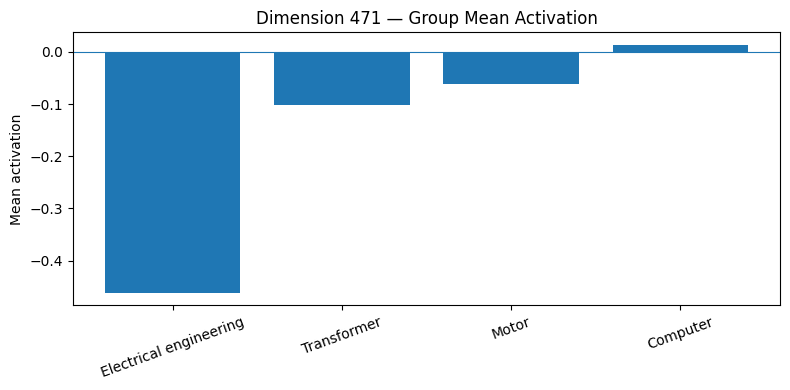

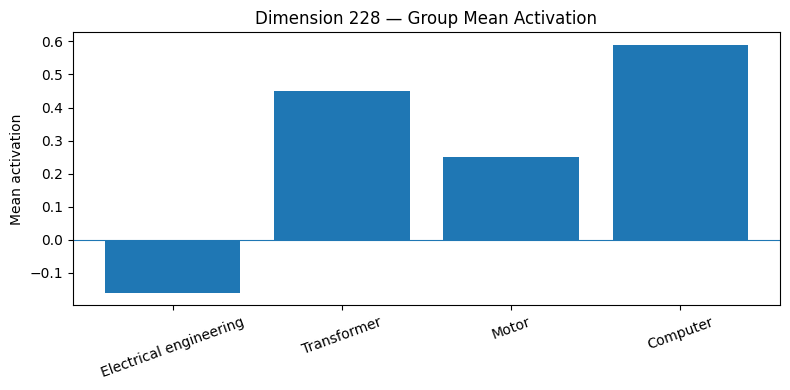

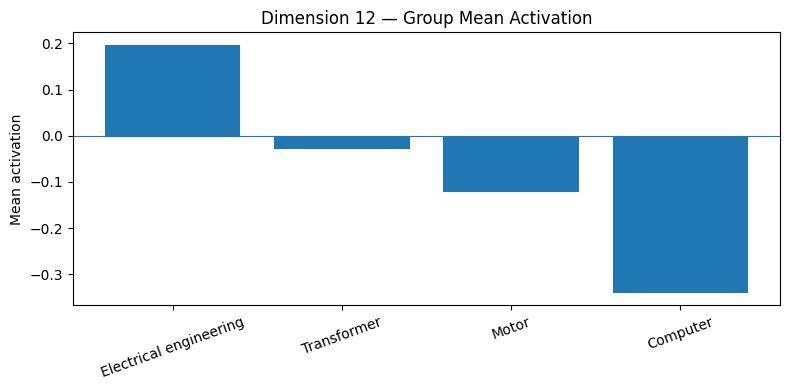

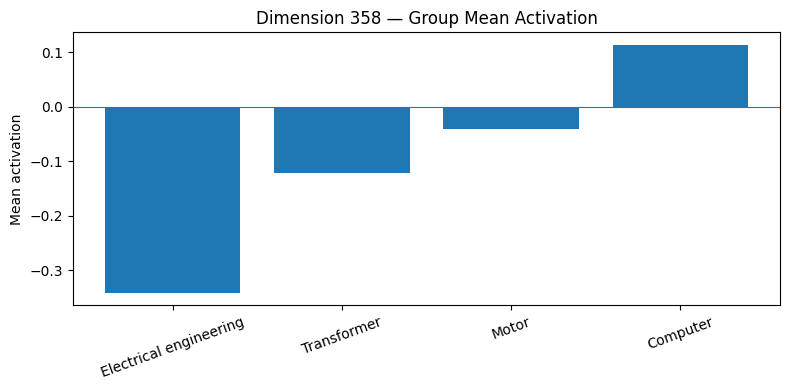

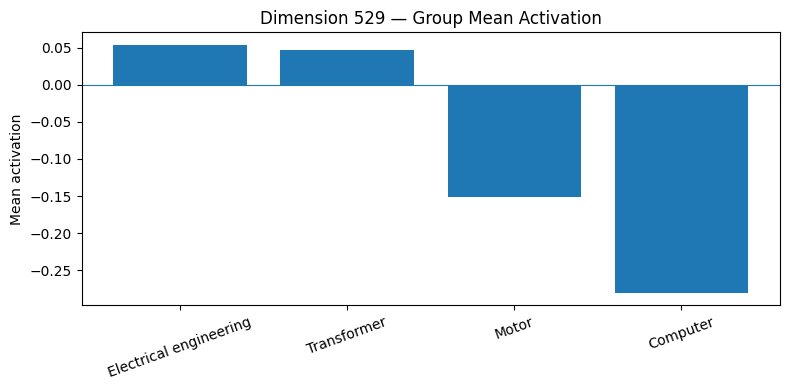

In [22]:
# ============================================================
# CANDIDATE DIMENSION GROUP PROFILES
# Amaç:
# En yüksek separation ratio gösteren 5 dimension'ın
# dört kavram grubundaki ortalama activation değerlerini
# görselleştirmek.
#
# Bu grafik yalnızca observation (gözlem) içindir.
# Henüz causal (nedensel) bir sonuç çıkarmıyoruz.
# ============================================================

import matplotlib.pyplot as plt

# İlk 5 adayı seçiyoruz.
top_candidates = top_ratio_indices[:5]

# Her aday dimension için ayrı grafik oluşturuyoruz.
for dimension in top_candidates:

    dim = dimension.item()

    # Dört grubun ortalama activation değerlerini alıyoruz.
    means = group_means[:, dim].detach().numpy()

    plt.figure(figsize=(8, 4))

    plt.bar(group_names, means)

    plt.axhline(
        0,
        linewidth=0.8
    )

    plt.title(
        f"Dimension {dim} — Group Mean Activation"
    )

    plt.ylabel("Mean activation")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

In [23]:
# ============================================================
# CANDIDATE DIMENSION SUMMARY
# Amaç:
# En güçlü 5 candidate dimension'ı tek tabloda karşılaştırmak.
#
# Her aday için:
#   - Separation ratio
#   - 4 grubun ortalama activation değeri
#
# Böylece intervention için hangi candidate'ın
# daha anlamlı olduğunu kontrollü şekilde seçebiliriz.
# ============================================================

print(
    f"{'Dimension':>10} | "
    f"{'Ratio':>8} | "
    f"{'Electrical':>12} | "
    f"{'Transformer':>12} | "
    f"{'Motor':>10} | "
    f"{'Computer':>10}"
)

print("-" * 82)

for dimension in top_candidates:

    dim = dimension.item()

    print(
        f"{dim:10d} | "
        f"{separation_ratio[dim].item():8.3f} | "
        f"{group_means[0, dim].item():12.3f} | "
        f"{group_means[1, dim].item():12.3f} | "
        f"{group_means[2, dim].item():10.3f} | "
        f"{group_means[3, dim].item():10.3f}"
    )

 Dimension |    Ratio |   Electrical |  Transformer |      Motor |   Computer
----------------------------------------------------------------------------------
       471 |    6.264 |       -0.462 |       -0.102 |     -0.061 |      0.014
       228 |    4.093 |       -0.160 |        0.449 |      0.249 |      0.590
        12 |    3.939 |        0.197 |       -0.030 |     -0.121 |     -0.340
       358 |    3.731 |       -0.341 |       -0.122 |     -0.040 |      0.114
       529 |    3.445 |        0.054 |        0.046 |     -0.151 |     -0.280


In [24]:
# ============================================================
# BASELINE OUTPUT ANALYSIS
# Amaç:
# Intervention (müdahale) öncesinde modelin normal output
# davranışını kaydetmek.
#
# Her cümle için:
#   - Sonraki token
#   - Token probability
#
# Daha sonra aynı cümlelere internal intervention uygulayıp
# output değişimini baseline ile karşılaştıracağız.
# ============================================================

baseline_results = []

for text in texts:

    # Cümleyi tokenizer'a çeviriyoruz.
    inputs = tokenizer(text, return_tensors="pt")

    # Normal model forward pass.
    with torch.no_grad():
        outputs = model(**inputs)

    # Son input token'ından sonraki token için
    # logits değerlerini alıyoruz.
    next_token_logits = outputs.logits[0, -1, :]

    # Logits'i probability dağılımına çeviriyoruz.
    probabilities = torch.softmax(
        next_token_logits,
        dim=-1
    )

    # En yüksek olasılıklı token'ı buluyoruz.
    top_probability, top_token_id = torch.max(
        probabilities,
        dim=-1
    )

    # Token ID'yi okunabilir metne çeviriyoruz.
    top_token = tokenizer.decode(
        [top_token_id.item()]
    )

    baseline_results.append({
        "text": text,
        "token": top_token,
        "probability": top_probability.item()
    })

# Sonuçları yazdırıyoruz.
for i, result in enumerate(baseline_results, start=1):

    print(
        f"{i:2d}. "
        f"{result['text']:<55} "
        f"→ {repr(result['token']):>12} "
        f"({result['probability']:.4f})"
    )

 1. Electrical engineering is important.                    →         '\n' (0.1199)
 2. Electrical engineering uses electricity.                →         '\n' (0.2197)
 3. Electrical engineering involves circuits.               →       ' The' (0.1424)
 4. Electrical engineering studies power systems.           →         '\n' (0.2724)
 5. The transformer is large.                               →       ' The' (0.1606)
 6. The transformer needs power.                            →         '\n' (0.1703)
 7. The transformer operates at high voltage.               →       ' The' (0.2057)
 8. The transformer transfers electrical energy.            →       ' The' (0.1627)
 9. The motor is rotating.                                  →       ' The' (0.1737)
10. The motor needs power.                                  →          '�' (0.1537)
11. The motor produces torque.                              →         '\n' (0.1834)
12. The motor converts electrical energy.                   →       ' The' (

In [26]:
# ============================================================
# FULL BASELINE OUTPUT DISTRIBUTION
# Amaç:
# Her cümle için modelin tüm vocabulary üzerindeki
# normal logits ve probability değerlerini kaydetmek.
#
# Daha sonra Dimension 471'e intervention uygulandığında
# bütün output distribution'ı baseline ile karşılaştıracağız.
#
# Candidate dimension:
#   471
#
# Bu aşamada henüz müdahale yapmıyoruz.
# ============================================================

baseline_logits = []
baseline_probabilities = []

for text in texts:

    # Cümleyi tokenizer'a çeviriyoruz.
    inputs = tokenizer(text, return_tensors="pt")

    # Normal forward pass.
    with torch.no_grad():
        outputs = model(**inputs)

    # Son token konumundaki vocabulary logits.
    logits = outputs.logits[0, -1, :]

    # Logits → probability distribution.
    probabilities = torch.softmax(
        logits,
        dim=-1
    )

    baseline_logits.append(logits)
    baseline_probabilities.append(probabilities)

# Listeleri tensor haline getiriyoruz.
baseline_logits = torch.stack(baseline_logits)
baseline_probabilities = torch.stack(baseline_probabilities)

print("Baseline logits shape:",
      baseline_logits.shape)

print("Baseline probability shape:",
      baseline_probabilities.shape)

print()
print("Candidate dimension for intervention: 471")

Baseline logits shape: torch.Size([16, 50257])
Baseline probability shape: torch.Size([16, 50257])

Candidate dimension for intervention: 471


In [27]:
# ============================================================
# ACTIVATION INTERVENTION — DIMENSION 471
# Amaç:
# Transformer'ın son hidden representation'ında
# Dimension 471 değerini kontrollü olarak 0 yapmak.
#
# Bu işlem:
#   Ablation / activation intervention
#
# Burada modelin ağırlıklarını değiştirmiyoruz.
# Sadece forward pass sırasında internal activation'ı
# geçici olarak değiştiriyoruz.
#
# Böylece:
#   Normal model → Normal output
#   Müdahaleli model → Yeni output
# karşılaştırması yapabileceğiz.
# ============================================================

candidate_dimension = 471

def intervention_hook(module, inputs, output):
    """
    Forward hook:
    Modelin son hidden representation'ı üretildikten sonra
    candidate dimension'ın activation değerini değiştirir.
    """

    # Tensor'ün kopyasını oluşturuyoruz.
    # Böylece orijinal output'u doğrudan değiştirmiyoruz.
    modified_output = output.clone()

    # Son hidden representation'ın
    # candidate dimension'ını sıfırlıyoruz.
    modified_output[:, :, candidate_dimension] = 0.0

    return modified_output


# DistilGPT2'nin son Transformer bloğuna hook ekliyoruz.
hook_handle = model.transformer.h[
    -1
].register_forward_hook(intervention_hook)

print(
    f"Intervention hook aktif. "
    f"Target dimension: {candidate_dimension}"
)

Intervention hook aktif. Target dimension: 471


In [28]:
# ============================================================
# INTERVENED OUTPUT DISTRIBUTION
# Amaç:
# Dimension 471 sıfırlanmış halde modelin output
# distribution'ını kaydetmek.
#
# Daha sonra bunu baseline_probabilities ile karşılaştırarak
# intervention'ın model çıktısını ne kadar değiştirdiğini
# ölçeceğiz.
# ============================================================

intervened_logits = []
intervened_probabilities = []

for text in texts:

    # Cümleyi tokenizer'a çeviriyoruz.
    inputs = tokenizer(text, return_tensors="pt")

    # Hook aktif olduğu için Dimension 471
    # forward pass sırasında sıfırlanacak.
    with torch.no_grad():
        outputs = model(**inputs)

    # Son input token'ındaki output logits.
    logits = outputs.logits[0, -1, :]

    # Logits → probability distribution.
    probabilities = torch.softmax(
        logits,
        dim=-1
    )

    intervened_logits.append(logits)
    intervened_probabilities.append(probabilities)

# Tensor haline getiriyoruz.
intervened_logits = torch.stack(intervened_logits)
intervened_probabilities = torch.stack(intervened_probabilities)

print("Intervened logits shape:",
      intervened_logits.shape)

print("Intervened probability shape:",
      intervened_probabilities.shape)

Intervened logits shape: torch.Size([16, 50257])
Intervened probability shape: torch.Size([16, 50257])


In [29]:
# ============================================================
# INTERVENTION EFFECT ANALYSIS
# Amaç:
# Dimension 471'i sıfırlamanın model output'u üzerindeki
# etkisini ölçmek.
#
# Karşılaştırma:
#   Baseline probability
#          vs
#   Intervened probability
#
# Ölçümler:
#   1. L1 distribution change
#   2. En büyük probability değişimi
#   3. Top-1 token değişimi
# ============================================================

# Her cümlede vocabulary dağılımının ne kadar değiştiğini
# hesaplıyoruz.
probability_difference = (
    intervened_probabilities - baseline_probabilities
)

# Mutlak farkların toplamı:
# Output distribution'ın genel değişim miktarı.
l1_change = probability_difference.abs().sum(dim=1)

print("Dimension 471 intervention results:")
print()

for i, text in enumerate(texts):

    # Baseline top-1 token
    baseline_prob, baseline_id = torch.max(
        baseline_probabilities[i],
        dim=0
    )

    # Intervention sonrası top-1 token
    intervened_prob, intervened_id = torch.max(
        intervened_probabilities[i],
        dim=0
    )

    baseline_token = tokenizer.decode(
        [baseline_id.item()]
    )

    intervened_token = tokenizer.decode(
        [intervened_id.item()]
    )

    # Bu cümledeki en büyük probability değişimi.
    max_change = probability_difference[i].abs().max()

    print(f"{i+1:2d}. {text}")
    print(
        f"    Top-1: "
        f"{repr(baseline_token)} → "
        f"{repr(intervened_token)}"
    )
    print(
        f"    Probability: "
        f"{baseline_prob.item():.4f} → "
        f"{intervened_prob.item():.4f}"
    )
    print(
        f"    L1 change: {l1_change[i].item():.6f}"
    )
    print(
        f"    Max probability change: "
        f"{max_change.item():.6f}"
    )
    print()

Dimension 471 intervention results:

 1. Electrical engineering is important.
    Top-1: '\n' → '\n'
    Probability: 0.1199 → 0.1241
    L1 change: 0.035408
    Max probability change: 0.004177

 2. Electrical engineering uses electricity.
    Top-1: '\n' → '\n'
    Probability: 0.2197 → 0.2263
    L1 change: 0.036395
    Max probability change: 0.006676

 3. Electrical engineering involves circuits.
    Top-1: ' The' → '\n'
    Probability: 0.1424 → 0.1396
    L1 change: 0.039406
    Max probability change: 0.005382

 4. Electrical engineering studies power systems.
    Top-1: '\n' → '\n'
    Probability: 0.2724 → 0.2800
    L1 change: 0.038835
    Max probability change: 0.007606

 5. The transformer is large.
    Top-1: ' The' → ' The'
    Probability: 0.1606 → 0.1597
    L1 change: 0.006622
    Max probability change: 0.000922

 6. The transformer needs power.
    Top-1: '\n' → '\n'
    Probability: 0.1703 → 0.1722
    L1 change: 0.011458
    Max probability change: 0.001917

 7. 

In [31]:
# ============================================================
# RANDOM CONTROL INTERVENTION
# Amaç:
# Dimension 471'in etkisini rastgele bir dimension ile
# karşılaştırmak.
#
# Aynı intervention uygulanacak:
#   Candidate → Dimension 471
#   Control   → Random dimension
#
# Böylece gözlediğimiz output değişiminin
# 471'e özgü olup olmadığını test etmeye başlayacağız.
# ============================================================

import random

# Tekrarlanabilirlik için seed belirliyoruz.
random.seed(42)

# 471 dışından rastgele bir dimension seçiyoruz.
control_dimension = random.choice(
    [i for i in range(768) if i != candidate_dimension]
)

print("Candidate dimension:", candidate_dimension)
print("Random control dimension:", control_dimension)


def control_intervention_hook(module, inputs, output):
    """
    Random control dimension'ı sıfırlar.
    Candidate intervention ile aynı işlemi uygular.
    """

    modified_output = output.clone()

    modified_output[:, :, control_dimension] = 0.0

    return modified_output


# Önceki candidate hook'u kaldırıyoruz.
hook_handle.remove()

# Random control hook'unu ekliyoruz.
control_hook_handle = model.transformer.h[
    -1
].register_forward_hook(control_intervention_hook)

print("Random control hook aktif.")

Candidate dimension: 471
Random control dimension: 655
Random control hook aktif.


In [32]:
# ============================================================
# RANDOM CONTROL OUTPUT DISTRIBUTION
# Amaç:
# Random control dimension (655) sıfırlandığında modelin
# output distribution'ının nasıl değiştiğini ölçmek.
#
# Bu sonuç daha sonra Dimension 471 intervention'ı ile
# doğrudan karşılaştırılacak.
# ============================================================

control_logits = []
control_probabilities = []

for text in texts:

    # Cümleyi tokenizer'a çeviriyoruz.
    inputs = tokenizer(text, return_tensors="pt")

    # Random control hook aktif.
    with torch.no_grad():
        outputs = model(**inputs)

    # Son token konumundaki vocabulary logits.
    logits = outputs.logits[0, -1, :]

    # Probability distribution.
    probabilities = torch.softmax(
        logits,
        dim=-1
    )

    control_logits.append(logits)
    control_probabilities.append(probabilities)

# Tensor haline getiriyoruz.
control_logits = torch.stack(control_logits)
control_probabilities = torch.stack(control_probabilities)

print("Control logits shape:",
      control_logits.shape)

print("Control probability shape:",
      control_probabilities.shape)

Control logits shape: torch.Size([16, 50257])
Control probability shape: torch.Size([16, 50257])


In [33]:
# ============================================================
# CANDIDATE vs RANDOM CONTROL
# Amaç:
# Dimension 471 intervention'ının oluşturduğu output
# değişimini, random control dimension 655'in oluşturduğu
# değişimle karşılaştırmak.
#
# Aynı metrikleri kullanıyoruz:
#   1. L1 probability change
#   2. Maximum probability change
#   3. Top-1 token değişimi
# ============================================================

# Önce random control hook'u kaldırıyoruz.
control_hook_handle.remove()

# Candidate intervention hook'unu tekrar aktif ediyoruz.
hook_handle = model.transformer.h[
    -1
].register_forward_hook(intervention_hook)

# Candidate sonuçlarını yeniden hesaplamıyoruz;
# daha önce kaydettiğimiz sonuçları kullanıyoruz.
candidate_probabilities = intervened_probabilities

# Candidate probability değişimi.
candidate_difference = (
    candidate_probabilities - baseline_probabilities
)

candidate_l1 = candidate_difference.abs().sum(dim=1)

candidate_max_change = (
    candidate_difference.abs().max(dim=1).values
)


# ------------------------------------------------------------
# RANDOM CONTROL sonuçları
# ------------------------------------------------------------

control_difference = (
    control_probabilities - baseline_probabilities
)

control_l1 = control_difference.abs().sum(dim=1)

control_max_change = (
    control_difference.abs().max(dim=1).values
)


# ------------------------------------------------------------
# SONUÇLARI KARŞILAŞTIR
# ------------------------------------------------------------

print(
    f"{'No':>2} | "
    f"{'Candidate 471 L1':>17} | "
    f"{'Control 655 L1':>16} | "
    f"{'Ratio':>8}"
)

print("-" * 55)

for i in range(len(texts)):

    candidate_value = candidate_l1[i].item()
    control_value = control_l1[i].item()

    ratio = (
        candidate_value / control_value
        if control_value > 0
        else float("inf")
    )

    print(
        f"{i+1:2d} | "
        f"{candidate_value:17.6f} | "
        f"{control_value:16.6f} | "
        f"{ratio:8.3f}"
    )


# ------------------------------------------------------------
# GENEL ORTALAMA
# ------------------------------------------------------------

print()
print("Mean L1 change:")
print(
    f"Dimension 471 : "
    f"{candidate_l1.mean().item():.6f}"
)

print(
    f"Dimension 655 : "
    f"{control_l1.mean().item():.6f}"
)

print()

print("Mean maximum probability change:")
print(
    f"Dimension 471 : "
    f"{candidate_max_change.mean().item():.6f}"
)

print(
    f"Dimension 655 : "
    f"{control_max_change.mean().item():.6f}"
)

No |  Candidate 471 L1 |   Control 655 L1 |    Ratio
-------------------------------------------------------
 1 |          0.035408 |         0.022560 |    1.569
 2 |          0.036395 |         0.033246 |    1.095
 3 |          0.039406 |         0.021314 |    1.849
 4 |          0.038835 |         0.034228 |    1.135
 5 |          0.006622 |         0.004047 |    1.636
 6 |          0.011458 |         0.005729 |    2.000
 7 |          0.009111 |         0.002156 |    4.225
 8 |          0.009828 |         0.013374 |    0.735
 9 |          0.007410 |         0.016048 |    0.462
10 |          0.004596 |         0.020796 |    0.221
11 |          0.008880 |         0.018349 |    0.484
12 |          0.003311 |         0.014801 |    0.224
13 |          0.003189 |         0.000077 |   41.395
14 |          0.003649 |         0.012521 |    0.291
15 |          0.000085 |         0.001877 |    0.045
16 |          0.004595 |         0.004944 |    0.930

Mean L1 change:
Dimension 471 : 0.013924
D

In [34]:
# ============================================================
# MULTIPLE RANDOM CONTROLS
# Amaç:
# Tek bir random dimension yerine birden fazla random
# control dimension seçmek.
#
# Böylece Dimension 471'in etkisini bir "random baseline"
# dağılımıyla karşılaştırabileceğiz.
#
# Candidate dimension olan 471'i kontrollerden çıkarıyoruz.
# ============================================================

import random

# Tekrarlanabilir random seçim.
random.seed(123)

candidate_dimension = 471

# 471 dışındaki 20 farklı dimension'ı seçiyoruz.
random_control_dimensions = random.sample(
    [i for i in range(768) if i != candidate_dimension],
    20
)

print("Candidate dimension:", candidate_dimension)
print()
print("Random control dimensions:")

for i, dimension in enumerate(
    random_control_dimensions,
    start=1
):
    print(
        f"{i:2d}. Dimension {dimension}"
    )

Candidate dimension: 471

Random control dimensions:
 1. Dimension 53
 2. Dimension 274
 3. Dimension 89
 4. Dimension 417
 5. Dimension 272
 6. Dimension 110
 7. Dimension 39
 8. Dimension 388
 9. Dimension 550
10. Dimension 576
11. Dimension 340
12. Dimension 348
13. Dimension 163
14. Dimension 138
15. Dimension 345
16. Dimension 575
17. Dimension 341
18. Dimension 719
19. Dimension 251
20. Dimension 167


In [35]:
# ============================================================
# MULTIPLE RANDOM CONTROL EXPERIMENT
# Amaç:
# 20 random dimension'ın her birini tek tek sıfırlayıp,
# output probability dağılımında oluşturdukları değişimi
# ölçmek.
#
# Her dimension için:
#   - Aynı 16 cümle kullanılır.
#   - Aynı intervention yöntemi uygulanır.
#   - Mean L1 change hesaplanır.
#
# Daha sonra Dimension 471'i bu random dağılımla
# karşılaştıracağız.
# ============================================================

# Önce varsa aktif intervention hook'unu kaldırıyoruz.
try:
    hook_handle.remove()
except:
    pass

# Sonuçları burada tutacağız.
control_results = {}

for control_dimension in random_control_dimensions:

    # --------------------------------------------------------
    # Bu iteration için seçilen dimension'ı sıfırlayan hook.
    # --------------------------------------------------------
    def random_control_hook(module, inputs, output):
        modified_output = output.clone()
        modified_output[:, :, control_dimension] = 0.0
        return modified_output

    # Hook'u son Transformer block'una bağlıyoruz.
    control_handle = model.transformer.h[
        -1
    ].register_forward_hook(random_control_hook)

    # --------------------------------------------------------
    # 16 cümleyi tekrar çalıştırıyoruz.
    # --------------------------------------------------------
    control_probabilities_current = []

    for text in texts:

        inputs = tokenizer(
            text,
            return_tensors="pt"
        )

        with torch.no_grad():
            outputs = model(**inputs)

        logits = outputs.logits[0, -1, :]

        probabilities = torch.softmax(
            logits,
            dim=-1
        )

        control_probabilities_current.append(
            probabilities
        )

    # Listeyi tensor'a çeviriyoruz.
    control_probabilities_current = torch.stack(
        control_probabilities_current
    )

    # --------------------------------------------------------
    # Baseline'a göre probability değişimi.
    # --------------------------------------------------------
    difference = (
        control_probabilities_current
        - baseline_probabilities
    )

    # Her cümle için toplam probability değişimi.
    l1_change = difference.abs().sum(dim=1)

    # 16 cümlenin ortalama etkisi.
    mean_l1 = l1_change.mean().item()

    # Sonucu kaydet.
    control_results[control_dimension] = mean_l1

    # Bu iteration'ın hook'unu kaldırıyoruz.
    control_handle.remove()


# ------------------------------------------------------------
# SONUÇLARI YAZDIR
# ------------------------------------------------------------

print("Random control results:")
print()

for dimension, mean_l1 in control_results.items():

    print(
        f"Dimension {dimension:3d} "
        f"→ Mean L1 change: {mean_l1:.6f}"
    )

Random control results:

Dimension  53 → Mean L1 change: 0.022478
Dimension 274 → Mean L1 change: 0.009072
Dimension  89 → Mean L1 change: 0.018436
Dimension 417 → Mean L1 change: 0.008736
Dimension 272 → Mean L1 change: 0.008453
Dimension 110 → Mean L1 change: 0.009402
Dimension  39 → Mean L1 change: 0.007884
Dimension 388 → Mean L1 change: 0.010355
Dimension 550 → Mean L1 change: 0.024153
Dimension 576 → Mean L1 change: 0.010553
Dimension 340 → Mean L1 change: 0.015105
Dimension 348 → Mean L1 change: 0.017517
Dimension 163 → Mean L1 change: 0.012270
Dimension 138 → Mean L1 change: 0.021835
Dimension 345 → Mean L1 change: 0.015546
Dimension 575 → Mean L1 change: 0.011092
Dimension 341 → Mean L1 change: 0.008219
Dimension 719 → Mean L1 change: 0.009677
Dimension 251 → Mean L1 change: 0.024040
Dimension 167 → Mean L1 change: 0.034599


In [36]:
# ============================================================
# CANDIDATE RANKING
# Amaç:
# Dimension 471'in intervention etkisinin,
# 20 random control dimension arasındaki konumunu
# belirlemek.
#
# Hesaplanan değerler:
#   - Sıralama
#   - Random control ortalaması
#   - Random control medyanı
#   - Candidate'ın percentile konumu
# ============================================================

import numpy as np

candidate_mean_l1 = 0.013924

control_values = np.array(
    list(control_results.values())
)

# Büyükten küçüğe sıralıyoruz.
sorted_controls = sorted(
    control_results.items(),
    key=lambda x: x[1],
    reverse=True
)

# Candidate'dan daha güçlü kaç kontrol olduğunu buluyoruz.
num_controls_greater = np.sum(
    control_values > candidate_mean_l1
)

# Candidate'ın 20 kontrol içindeki sırası.
rank = num_controls_greater + 1

# Random kontrollerin ortalaması ve medyanı.
control_mean = control_values.mean()
control_median = np.median(control_values)

# Candidate'ın random kontrollerin yüzde kaçından
# daha güçlü olduğunu hesaplıyoruz.
percentile = (
    np.sum(control_values < candidate_mean_l1)
    / len(control_values)
    * 100
)

print("Dimension 471")
print("----------------------------")
print(f"Mean L1 change : {candidate_mean_l1:.6f}")
print(f"Rank           : {rank} / {len(control_values) + 1}")
print(f"Controls greater: {num_controls_greater}")
print(f"Control mean   : {control_mean:.6f}")
print(f"Control median : {control_median:.6f}")
print(f"Percentile     : {percentile:.1f}%")

print()
print("Random controls sorted:")
print()

for i, (dimension, value) in enumerate(
    sorted_controls,
    start=1
):
    print(
        f"{i:2d}. Dimension {dimension:3d}"
        f" → {value:.6f}"
    )

Dimension 471
----------------------------
Mean L1 change : 0.013924
Rank           : 10 / 21
Controls greater: 9
Control mean   : 0.014971
Control median : 0.011681
Percentile     : 55.0%

Random controls sorted:

 1. Dimension 167 → 0.034599
 2. Dimension 550 → 0.024153
 3. Dimension 251 → 0.024040
 4. Dimension  53 → 0.022478
 5. Dimension 138 → 0.021835
 6. Dimension  89 → 0.018436
 7. Dimension 348 → 0.017517
 8. Dimension 345 → 0.015546
 9. Dimension 340 → 0.015105
10. Dimension 163 → 0.012270
11. Dimension 575 → 0.011092
12. Dimension 576 → 0.010553
13. Dimension 388 → 0.010355
14. Dimension 719 → 0.009677
15. Dimension 110 → 0.009402
16. Dimension 274 → 0.009072
17. Dimension 417 → 0.008736
18. Dimension 272 → 0.008453
19. Dimension 341 → 0.008219
20. Dimension  39 → 0.007884
